In [3]:
# SALES FUNNEL & PIPELINE ANALYTICS SYSTEM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# LOAD DATASET

url = "https://raw.githubusercontent.com/selva86/datasets/master/bank-full.csv"
df = pd.read_csv(url, sep=";")

df = df.copy()

In [5]:
# BASIC CLEANING

df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [6]:
# SIMULATED GTM FUNNEL

df['contacted'] = 1
df['engaged'] = np.where(df['duration'] > df['duration'].median(), 1, 0)
df['converted'] = df['y']

In [7]:
# FUNNEL METRICS

funnel = pd.DataFrame({
    "Stage": ["Contacted", "Engaged", "Converted"],
    "Users": [
        df['contacted'].sum(),
        df['engaged'].sum(),
        df['converted'].sum()
    ]
})

funnel["Conversion Rate"] = funnel["Users"] / funnel["Users"].iloc[0]

print("\n=== SALES FUNNEL METRICS ===\n")
print(funnel)


=== SALES FUNNEL METRICS ===

       Stage  Users  Conversion Rate
0  Contacted  41188         1.000000
1    Engaged  20483         0.497305
2  Converted   4640         0.112654


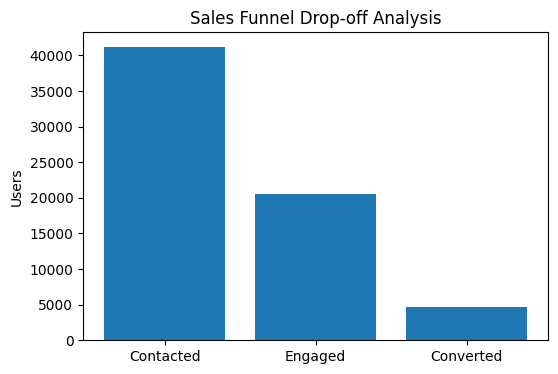

In [8]:
# VISUALIZATION

plt.figure(figsize=(6,4))
plt.bar(funnel["Stage"], funnel["Users"])
plt.title("Sales Funnel Drop-off Analysis")
plt.ylabel("Users")
plt.show()

In [9]:
# PIPELINE INSIGHTS

print("\n=== KEY INSIGHTS ===")
print(f"Overall Conversion Rate: {df['converted'].mean():.2%}")
print(f"Engagement Rate: {df['engaged'].mean():.2%}")
print(f"Avg Call Duration: {df['duration'].mean():.2f} sec")


=== KEY INSIGHTS ===
Overall Conversion Rate: 11.27%
Engagement Rate: 49.73%
Avg Call Duration: 258.29 sec
